# FER2013 Training Experiments

This notebook is designed for Colab or Kaggle GPU training. It uses the dataset analysis from `01_data_exploration.ipynb` to justify the experiment protocol: a CNN trained from scratch for native 48x48 grayscale inputs, augmentation for low-resolution face variability, ResNet18 transfer learning for pretrained visual features, and imbalance-aware training for uneven emotion counts.


## 1. Setup

For Colab, clone your GitHub repository or upload it to Drive. For Kaggle, add the FER2013 image-folder dataset and set `DATA_DIR` to the Kaggle input path.


In [ ]:
# Optional in Colab/Kaggle if dependencies are missing:
# !pip install -q torch torchvision pandas scikit-learn matplotlib seaborn tqdm

In [1]:
# Comment this section if you are running your notebook in kaggle
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT / 'src'))

# Local path after extracting Kaggle data:
DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'fer2013_images'

# Kaggle example, uncomment and edit if needed:
# DATA_DIR = Path('/kaggle/input/fer2013')

RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)
DATA_DIR


PosixPath('/kaggle/working/data/raw/fer2013_images')

### Kaggle Path Setup Option

Use this block only when running the notebook in Kaggle. Keep the local setup cell above for local runs. In Kaggle, comment out the local `PROJECT_ROOT`, `sys.path`, and `DATA_DIR` lines above, then uncomment and edit the Kaggle paths below. The Kaggle code path should point to the cloned repository, while `DATA_DIR` should point to the Kaggle FER2013 dataset folder.


In [1]:
# Kaggle option. Uncomment this block only when running in Kaggle.

%cd /kaggle/working
import os
from pathlib import Path
# !git clone https://github.com/zsykk/DL-final-project.git
REPO_URL = "https://github.com/zsykk/DL-final-project.git"
REPO_DIR = "DL-final-project"

if Path(REPO_DIR).exists():
    %cd /kaggle/working/DL-final-project
    !git pull
else:
    !git clone {REPO_URL}
    %cd /kaggle/working/DL-final-project


from pathlib import Path
import sys

PROJECT_ROOT = Path('/kaggle/working/DL-final-project')  # cloned repo folder
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

DATA_DIR = Path('/kaggle/input/datasets/msambare/fer2013')  # edit if your Kaggle dataset folder name differs
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

DATA_DIR, (DATA_DIR / "train").exists(), (DATA_DIR / "test").exists()
PROJECT_ROOT, PROJECT_ROOT.exists(), (PROJECT_ROOT / 'src' / 'fer_project').exists(), DATA_DIR, DATA_DIR.exists()


/kaggle/working
Cloning into 'DL-final-project'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 79 (delta 33), reused 64 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 572.00 KiB | 1.63 MiB/s, done.
Resolving deltas: 100% (33/33), done.
/kaggle/working/DL-final-project


(PosixPath('/kaggle/working/DL-final-project'),
 True,
 True,
 PosixPath('/kaggle/input/datasets/msambare/fer2013'),
 True)

In [2]:
import importlib
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

from fer_project.data import TransformConfig, build_imagefolder_dataloaders, class_weights, dataset_labels
import fer_project.metrics as metrics

metrics = importlib.reload(metrics)
collect_predictions = metrics.collect_predictions
plot_confusion_matrix = metrics.plot_confusion_matrix
save_classification_report = metrics.save_classification_report
top_confusions = metrics.top_confusions

from fer_project.models import build_model
import fer_project.training as training
training = importlib.reload(training)
fit = training.fit

import fer_project.data as data
data = importlib.reload(data)

import fer_project.metrics as metrics
metrics = importlib.reload(metrics)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE


device(type='cuda')

## 2. Experiment Configurations

The experiments are organized as a gradual tuning path. The baseline CNN already includes standard architecture and optimization choices such as BatchNorm, Dropout, ReLU, MaxPool, and AdamW, because these are normal parts of building a reasonable CNN baseline rather than dataset-specific tricks. The gradual tuning focuses on FER2013-specific choices: data augmentation for small grayscale face images, class weighting or sampling for imbalance, focal loss for hard/minority examples, and transfer-learning settings. This makes it possible to explain which tuning choices improve the baseline before comparing the best tuned CNN against transfer learning. ResNet18 is the main pretrained baseline because it is a widely used, moderate-size ImageNet-pretrained residual network. It is deep enough to provide useful generic visual features such as edges, textures, facial parts, and object/shape patterns, but small enough to fine-tune on FER2013 without making the project unnecessarily expensive. A nonstandard model such as ResNet15 is not used because it is not a canonical pretrained torchvision architecture, so it would not provide the same reproducible transfer-learning baseline. MobileNetV2 is kept as an additional pretrained strategy because it tests a different question: whether a lightweight, efficient backbone can transfer useful features to FER2013 with fewer parameters and lower computational cost.


In [12]:
CORE_EXPERIMENTS = [
    {
        'name': 'baseline_cnn',
        'group': 'required',
        'model_kind': 'baseline_cnn',
        'train_config': TransformConfig(image_size=48, channels=1, augment=False),
        'eval_config': TransformConfig(image_size=48, channels=1, augment=False),
        'lr': 1e-3,
        'epochs': 20,
        'use_class_weights': False,
        'weighted_sampler': False,
        'loss_name': 'cross_entropy',
    },
    {
        'name': 'baseline_cnn_aug',
        'group': 'required',
        'model_kind': 'baseline_cnn',
        'train_config': TransformConfig(image_size=48, channels=1, augment=True),
        'eval_config': TransformConfig(image_size=48, channels=1, augment=False),
        'lr': 1e-3,
        'epochs': 20,
        'use_class_weights': False,
        'weighted_sampler': False,
        'loss_name': 'cross_entropy',
    },
    {
        'name': 'resnet18_frozen',
        'group': 'required',
        'model_kind': 'transfer',
        'transfer_model': 'resnet18',
        'freeze_backbone': True,
        'train_config': TransformConfig(image_size=224, channels=3, augment=True, imagenet_norm=True),
        'eval_config': TransformConfig(image_size=224, channels=3, augment=False, imagenet_norm=True),
        'lr': 1e-3,
        'epochs': 20,
        'use_class_weights': False,
        'weighted_sampler': False,
        'loss_name': 'cross_entropy',
    },
    {
        'name': 'resnet18_finetune',
        'group': 'required',
        'model_kind': 'transfer',
        'transfer_model': 'resnet18',
        'freeze_backbone': False,
        'train_config': TransformConfig(image_size=224, channels=3, augment=True, imagenet_norm=True),
        'eval_config': TransformConfig(image_size=224, channels=3, augment=False, imagenet_norm=True),
        'lr': 1e-4,
        'epochs': 20,
        'use_class_weights': False,
        'weighted_sampler': False,
        'loss_name': 'cross_entropy',
    },
    {
        'name': 'baseline_cnn_aug_class_weights',
        'group': 'required',
        'model_kind': 'baseline_cnn',
        'train_config': TransformConfig(image_size=48, channels=1, augment=True),
        'eval_config': TransformConfig(image_size=48, channels=1, augment=False),
        'lr': 1e-3,
        'epochs': 20,
        'use_class_weights': True,
        'weighted_sampler': False,
        'loss_name': 'cross_entropy',
    },
]

OPTIONAL_EXPERIMENTS = [
    {
        'name': 'baseline_cnn_aug_weighted_sampler',
        'group': 'optional_imbalance',
        'model_kind': 'baseline_cnn',
        'train_config': TransformConfig(image_size=48, channels=1, augment=True),
        'eval_config': TransformConfig(image_size=48, channels=1, augment=False),
        'lr': 1e-3,
        'epochs': 20,
        'use_class_weights': False,
        'weighted_sampler': True,
        'loss_name': 'cross_entropy',
    },
    {
        'name': 'baseline_cnn_aug_focal_loss',
        'group': 'optional_imbalance',
        'model_kind': 'baseline_cnn',
        'train_config': TransformConfig(image_size=48, channels=1, augment=True),
        'eval_config': TransformConfig(image_size=48, channels=1, augment=False),
        'lr': 1e-3,
        'epochs': 20,
        'use_class_weights': False,
        'weighted_sampler': False,
        'loss_name': 'focal',
        'focal_gamma': 2.0,
    },
    {
        'name': 'mobilenet_v2_frozen',
        'group': 'optional_transfer',
        'model_kind': 'transfer',
        'transfer_model': 'mobilenet_v2',
        'freeze_backbone': True,
        'train_config': TransformConfig(image_size=224, channels=3, augment=True, imagenet_norm=True),
        'eval_config': TransformConfig(image_size=224, channels=3, augment=False, imagenet_norm=True),
        'lr': 1e-3,
        'epochs': 20,
        'use_class_weights': False,
        'weighted_sampler': False,
        'loss_name': 'cross_entropy',
    },
    {
        'name': 'mobilenet_v2_finetune',
        'group': 'optional_transfer',
        'model_kind': 'transfer',
        'transfer_model': 'mobilenet_v2',
        'freeze_backbone': False,
        'train_config': TransformConfig(image_size=224, channels=3, augment=True, imagenet_norm=True),
        'eval_config': TransformConfig(image_size=224, channels=3, augment=False, imagenet_norm=True),
        'lr': 1e-4,
        'epochs': 20,
        'use_class_weights': False,
        'weighted_sampler': False,
        'loss_name': 'cross_entropy',
    },
]

# Set RUN_OPTIONAL_EXPERIMENTS = True when you have enough GPU time.
RUN_OPTIONAL_EXPERIMENTS = False
EXPERIMENTS = CORE_EXPERIMENTS + (OPTIONAL_EXPERIMENTS if RUN_OPTIONAL_EXPERIMENTS else [])


### Why ResNet18 and MobileNetV2?

The dataset analysis shows that FER2013 images are small, grayscale, imbalanced, and visually ambiguous. A custom CNN is useful because it matches the native 48x48 grayscale input and gives a fair from-scratch baseline. This baseline still uses standard deep-learning improvements: BatchNorm stabilizes activations and helps optimization, Dropout/Dropout2d reduces overfitting, ReLU adds nonlinearity, MaxPool gradually reduces spatial size, AdamW adds decoupled weight decay, and the separate augmentation/class-weight/sampler/focal-loss experiments test common regularization and imbalance strategies. Therefore, the baseline is a practical optimized CNN baseline, not a deliberately simple straw-man model.

ResNet18 is the main pretrained model because it is a standard, moderate-size ImageNet backbone with residual skip connections. The residual design makes it easier to train deeper convolutional models than plain CNNs, while the ImageNet pretraining gives the network reusable low- and mid-level visual features such as edges, corners, textures, contrast patterns, and local shapes. These features are not specific to ImageNet classes; they are also useful for facial-expression images, where the model must detect visual patterns around the eyes, mouth, eyebrows, and face outline. ResNet18 is therefore a reasonable transfer-learning choice for FER2013: it is expressive enough to improve over a small custom CNN, but not as computationally heavy or over-parameterized as larger ResNets such as ResNet50 or ResNet101 for this project scale.

A model such as ResNet15 is not selected because it is not a standard pretrained torchvision model. Using it would either require training from scratch or using a custom checkpoint, which would weaken the comparison and make the experiment less reproducible. ResNet18 is preferred because its pretrained weights are readily available, well documented, and commonly used as a baseline in transfer-learning experiments.

MobileNetV2 is included as a second pretrained strategy, not as a replacement for ResNet18. Its purpose is different: it is a lightweight architecture designed for efficiency, so it lets the report compare a standard transfer backbone against a smaller transfer backbone. If MobileNetV2 performs close to ResNet18, that is useful evidence for computational efficiency; if it performs worse, that supports using the stronger ResNet18 model.

For both pretrained models, FER2013 images are converted from 48x48 grayscale to 224x224 RGB tensors with ImageNet normalization. Frozen experiments test whether fixed pretrained features are useful; fine-tuned experiments test whether adapting the whole backbone improves performance on FER2013.


## 3. Train One Experiment

Start with a tiny smoke test to confirm the code path works: one epoch, a small class-stratified subset, and `num_workers=0`. Then increase `subset_fraction` and epochs gradually. Transfer models must use the exact input adaptation justified in the data notebook: 48x48 grayscale FER2013 images are resized to 224x224, repeated into 3 channels, and normalized with ImageNet statistics for ResNet18.


In [4]:
def run_experiment(config, batch_size=128, num_workers=0, subset_fraction=1.0):
    name = config['name']
    loaders, datasets = build_imagefolder_dataloaders(
        DATA_DIR,
        train_config=config['train_config'],
        eval_config=config['eval_config'],
        batch_size=batch_size,
        num_workers=num_workers,
        weighted_sampler=config.get('weighted_sampler', False),
        val_fraction=0.1,
        subset_fraction=subset_fraction,
        seed=42,
    )
    if config['model_kind'] == 'baseline_cnn':
        model = build_model('baseline_cnn')
    else:
        model = build_model(
            'transfer',
            transfer_model=config.get('transfer_model', 'resnet18'),
            freeze_backbone=config.get('freeze_backbone', True),
        )

    weights = class_weights(dataset_labels(datasets['train'])) if config.get('use_class_weights') else None
    checkpoint_path = RESULTS_DIR / 'checkpoints' / f'{name}.pt'
    history = fit(
        model,
        loaders,
        device=DEVICE,
        epochs=config['epochs'],
        lr=config['lr'],
        class_weight=weights,
        loss_name=config.get('loss_name', 'cross_entropy'),
        focal_gamma=config.get('focal_gamma', 2.0),
        checkpoint_path=checkpoint_path,
    )

    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    y_true, y_pred = collect_predictions(model, loaders['test'], DEVICE)

    report_path = RESULTS_DIR / 'metrics' / f'{name}_classification_report.csv'
    report = save_classification_report(y_true, y_pred, report_path)
    confusions = top_confusions(y_true, y_pred, top_n=10)
    confusions.to_csv(RESULTS_DIR / 'metrics' / f'{name}_top_confusions.csv', index=False)
    plot_confusion_matrix(y_true, y_pred, RESULTS_DIR / 'figures' / f'{name}_confusion_matrix.png')

    history_frame = pd.DataFrame(history)
    history_frame.to_csv(RESULTS_DIR / 'metrics' / f'{name}_history.csv', index=False)
    return history_frame, report, confusions


### Loss Curve Helper

Use this after each experiment to inspect convergence and possible overfitting from train/validation loss.


In [6]:
def plot_loss_curve(history, title):
    ax = history.plot(
        x='epoch',
        y=['train_loss', 'val_loss'],
        marker='o',
        figsize=(5, 3),
        title=title,
    )
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    plt.tight_layout()
    plt.show()
    return ax


## 4. Small Smoke Tests

Run these before the full experiment loop. They use one epoch and a small class-stratified subset, so they are only for checking that the dataloaders, model, training loop, metrics, and saved outputs work. Do not use these numbers as final results.


  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 2.1705, 'train_accuracy': 0.2011, 'val_loss': 1.8432, 'val_accuracy': 0.2098}


  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

...

  0%|          | 0/5 [00:00<?, ?it/s]

{'epoch': 4, 'train_loss': 1.7816, 'train_accuracy': 0.2554, 'val_loss': 1.7975, 'val_accuracy': 0.2448}


  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

{'epoch': 5, 'train_loss': 1.7572, 'train_accuracy': 0.2562, 'val_loss': 1.8114, 'val_accuracy': 0.2657}


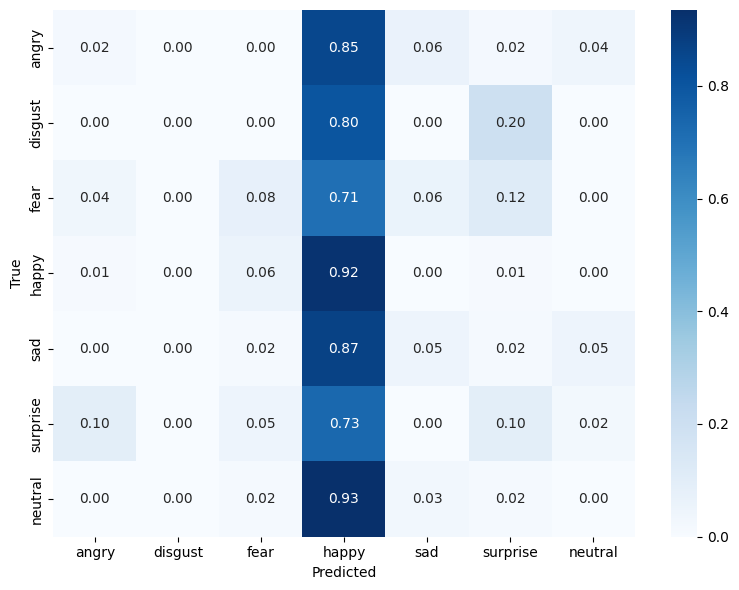

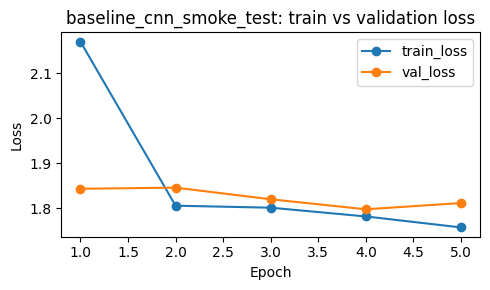

,epoch,train_loss,val_loss
0,1,2.170498,1.843168
1,2,1.805528,1.845688
2,3,1.801099,1.819830
3,4,1.781598,1.797542
4,5,1.757170,1.811395


,precision,recall,f1-score,support
macro avg,0.177185,0.166587,0.114542,355.0
weighted avg,0.205669,0.261972,0.156594,355.0


,true_emotion,predicted_emotion,count,true_class_rate
22,neutral,happy,57,0.934426
14,sad,happy,54,0.870968
0,angry,happy,40,0.851064
7,fear,happy,36,0.705882
19,surprise,happy,30,0.731707
9,fear,surprise,6,0.117647
11,happy,fear,5,0.056818
4,disgust,happy,4,0.800000
17,surprise,angry,4,0.097561
1,angry,sad,3,0.063830


In [11]:
# Fast CPU/GPU sanity check for the baseline CNN.
smoke_config = {**CORE_EXPERIMENTS[0], 'epochs': 5}
history, report, confusions = run_experiment(
    smoke_config,
    batch_size=32,
    num_workers=0,
    subset_fraction=0.05,
)
plot_loss_curve(history, 'baseline_cnn_smoke_test: train vs validation loss')
display(history[['epoch', 'train_loss', 'val_loss']])
display(report.loc[['macro avg', 'weighted avg']])
display(confusions)


  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.9265, 'train_accuracy': 0.2047, 'val_loss': 1.8524, 'val_accuracy': 0.193}


  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

...

  0%|          | 0/4 [00:00<?, ?it/s]

{'epoch': 4, 'train_loss': 1.7034, 'train_accuracy': 0.3158, 'val_loss': 1.6907, 'val_accuracy': 0.3333}


  0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

{'epoch': 5, 'train_loss': 1.6972, 'train_accuracy': 0.2865, 'val_loss': 1.6697, 'val_accuracy': 0.2807}


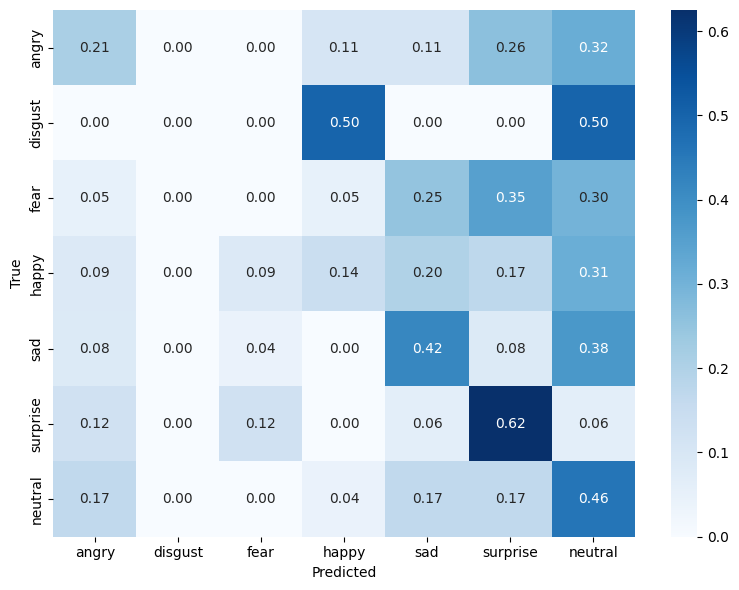

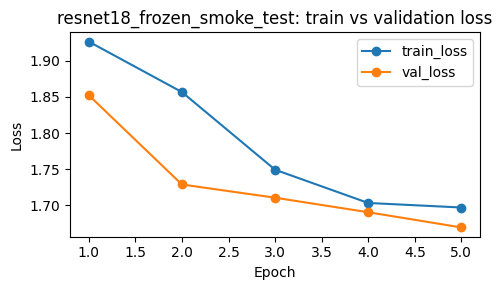

,epoch,train_loss,val_loss
0,1,1.926453,1.852382
1,2,1.856732,1.728997
2,3,1.749409,1.710735
3,4,1.703447,1.690654
4,5,1.697196,1.669651


,precision,recall,f1-score,support
macro avg,0.233341,0.264769,0.220999,140.0
weighted avg,0.293560,0.285714,0.251639,140.0


,true_emotion,predicted_emotion,count,true_class_rate
15,happy,neutral,11,0.314286
19,sad,neutral,9,0.375000
9,fear,surprise,7,0.350000
13,happy,sad,7,0.200000
3,angry,neutral,6,0.315789
10,fear,neutral,6,0.300000
14,happy,surprise,6,0.171429
2,angry,surprise,5,0.263158
8,fear,sad,5,0.250000
24,neutral,angry,4,0.166667


In [12]:
# Fast transfer-learning smoke test.
# Uses a tiny subset because ResNet18 resizes FER2013 images to 224x224.
transfer_smoke_config = {**CORE_EXPERIMENTS[2], 'epochs': 5}
history, report, confusions = run_experiment(
    transfer_smoke_config,
    batch_size=16,
    num_workers=0,
    subset_fraction=0.02,
)
plot_loss_curve(history, 'resnet18_frozen_smoke_test: train vs validation loss')
display(history[['epoch', 'train_loss', 'val_loss']])
display(report.loc[['macro avg', 'weighted avg']])
display(confusions)


## 5. Run Experiments Safely

Run one stage at a time. After each stage, inspect the validation curve, macro F1, per-class metrics, and top confusions before deciding whether the next tuning step is justified. This supports the report narrative: dataset observation, tuning choice, result, and conclusion. Each run saves outputs under `results/`, so you can merge completed results later without retraining everything.


In [7]:
EXPERIMENTS_BY_NAME = {config['name']: config for config in CORE_EXPERIMENTS + OPTIONAL_EXPERIMENTS}

def run_stage(experiment_name, batch_size=128, num_workers=0, subset_fraction=1.0):
    history, report, confusions = run_experiment(
        EXPERIMENTS_BY_NAME[experiment_name],
        batch_size=batch_size,
        num_workers=num_workers,
        subset_fraction=subset_fraction,
    )
    plot_loss_curve(history, f'{experiment_name}: train vs validation loss')
    display(history[['epoch', 'train_loss', 'val_loss']])
    display(report.loc[['macro avg', 'weighted avg']])
    display(report.loc[['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral'], ['precision', 'recall', 'f1-score', 'support']])
    display(confusions)
    return history, report, confusions


### Stage 1: Baseline CNN

Start with the self-defined CNN using standard architecture choices such as BatchNorm and Dropout. This gives the reference result before adding FER2013-specific tuning.


In [33]:
from pathlib import Path

for path in Path("/kaggle/input/datasets").rglob("*"):
    if path.is_dir() and (path / "train").exists() and (path / "test").exists():
        print(path)

/kaggle/input/datasets/msambare/fer2013


KeyboardInterrupt: 

  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.826, 'train_accuracy': 0.2636, 'val_loss': 1.6826, 'val_accuracy': 0.3066}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 19, 'train_loss': 0.9946, 'train_accuracy': 0.6109, 'val_loss': 1.0825, 'val_accuracy': 0.5899}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 20, 'train_loss': 0.9719, 'train_accuracy': 0.623, 'val_loss': 1.0916, 'val_accuracy': 0.5958}


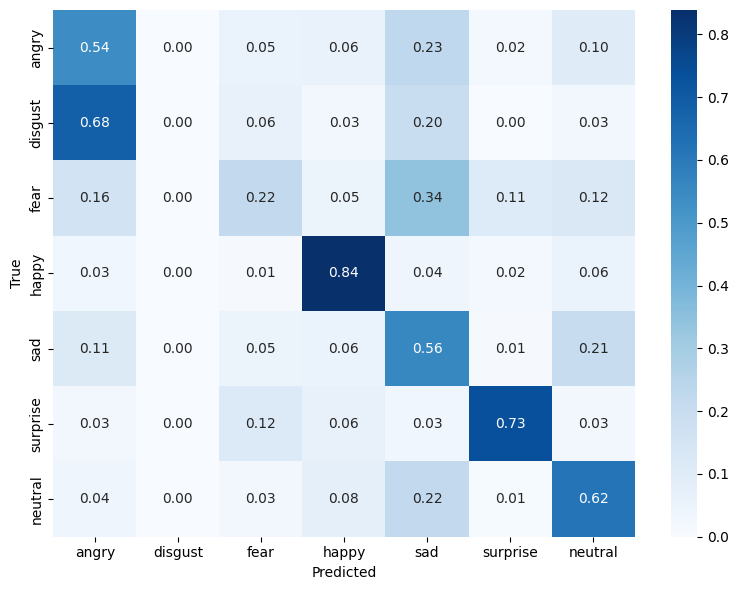

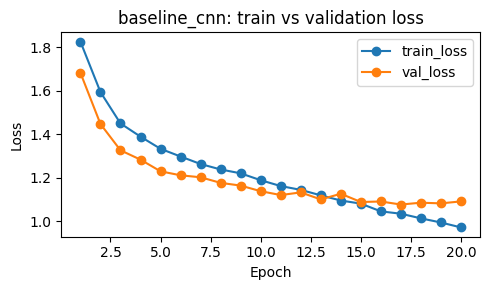

,epoch,train_loss,val_loss
0,1,1.825951,1.682613
1,2,1.594117,1.447356
2,3,1.449856,1.326514
3,4,1.389186,1.283442
4,5,1.333262,1.229865
5,6,1.297890,1.211538
6,7,1.263375,1.202443
7,8,1.238335,1.176808
8,9,1.220608,1.164220
9,10,1.189018,1.138511


,precision,recall,f1-score,support
macro avg,0.500676,0.500942,0.493302,7178.0
weighted avg,0.589496,0.598495,0.586145,7178.0


,precision,recall,f1-score,support
angry,0.503408,0.539666,0.520907,958.0
disgust,0.000000,0.000000,0.000000,111.0
fear,0.450704,0.218750,0.294543,1024.0
happy,0.816685,0.838782,0.827586,1774.0
sad,0.419433,0.557338,0.478650,1247.0
surprise,0.758706,0.734055,0.746177,831.0
neutral,0.555799,0.618005,0.585253,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
12,fear,sad,351,0.342773
33,neutral,sad,274,0.222222
24,sad,neutral,257,0.206095
2,angry,sad,218,0.227557
10,fear,angry,162,0.158203
20,sad,angry,143,0.114675
14,fear,neutral,126,0.123047
13,fear,surprise,114,0.111328
19,happy,neutral,103,0.058061
32,neutral,happy,100,0.081103


In [34]:
history, report, confusions = run_stage('baseline_cnn')


### Stage 2: Add Data Augmentation

Run this after reviewing the baseline. The reason for this tuning step is FER2013-specific: small 48x48 grayscale face images can overfit, so augmentation tests whether small image variations improve generalization.


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.8396, 'train_accuracy': 0.2526, 'val_loss': 1.7487, 'val_accuracy': 0.2885}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 19, 'train_loss': 1.1956, 'train_accuracy': 0.5486, 'val_loss': 1.0847, 'val_accuracy': 0.5979}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 20, 'train_loss': 1.1853, 'train_accuracy': 0.5506, 'val_loss': 1.0528, 'val_accuracy': 0.5958}


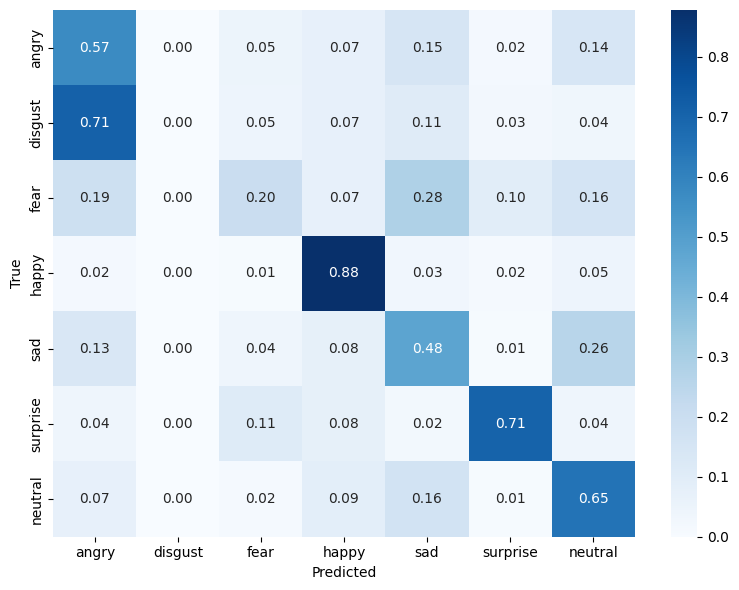

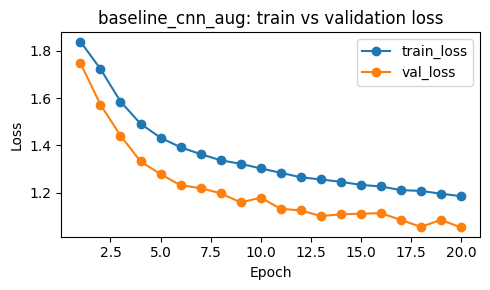

,epoch,train_loss,val_loss
0,1,1.839566,1.748668
1,2,1.723887,1.572775
2,3,1.585930,1.441774
3,4,1.491982,1.332279
4,5,1.432805,1.278510
5,6,1.392099,1.231206
6,7,1.363267,1.219163
7,8,1.337346,1.197525
8,9,1.322070,1.158634
9,10,1.302650,1.178901


,precision,recall,f1-score,support
macro avg,0.498386,0.498103,0.488317,7178.0
weighted avg,0.583838,0.598774,0.581001,7178.0


,precision,recall,f1-score,support
angry,0.476856,0.569937,0.519258,958.0
disgust,0.000000,0.000000,0.000000,111.0
fear,0.471655,0.203125,0.283959,1024.0
happy,0.787159,0.877678,0.829957,1774.0
sad,0.452687,0.479551,0.465732,1247.0
surprise,0.779255,0.705174,0.740366,831.0
neutral,0.521090,0.651257,0.578947,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
25,sad,neutral,323,0.259022
13,fear,sad,289,0.282227
34,neutral,sad,203,0.164639
11,fear,angry,191,0.186523
21,sad,angry,168,0.134723
15,fear,neutral,160,0.156250
2,angry,sad,142,0.148225
4,angry,neutral,136,0.141962
33,neutral,happy,109,0.088402
14,fear,surprise,100,0.097656


In [35]:
history_aug, report_aug, confusions_aug = run_stage('baseline_cnn_aug')


### Stage 3: Add Class Weights

Run this if the baseline or augmented model shows weak minority-class performance. The reason for this tuning step is class imbalance, especially the small `disgust` class.


In [41]:
import inspect
print(inspect.getsource(class_weights))

def class_weights(labels: np.ndarray, num_classes: int = 7) -> torch.Tensor:
    """Compute inverse-frequency class weights normalized around one.

    Args:
        labels: Integer class labels for a dataset split.
        num_classes: Total number of expected emotion classes.

    Returns:
        Float tensor of per-class weights suitable for cross-entropy loss.
    """
    counts = np.bincount(labels, minlength=num_classes)
    print("USING SQRT WEIGHTS")
    # weights = counts.sum() / np.maximum(counts, 1)
    weights = 1.0 / np.sqrt(np.maximum(counts, 1))
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32)



USING SQRT WEIGHTS


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.9095, 'train_accuracy': 0.2345, 'val_loss': 1.8267, 'val_accuracy': 0.2882}


  0%|          | 0/202 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 19, 'train_loss': 1.3508, 'train_accuracy': 0.5004, 'val_loss': 1.1967, 'val_accuracy': 0.561}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 20, 'train_loss': 1.3419, 'train_accuracy': 0.5015, 'val_loss': 1.1957, 'val_accuracy': 0.5836}


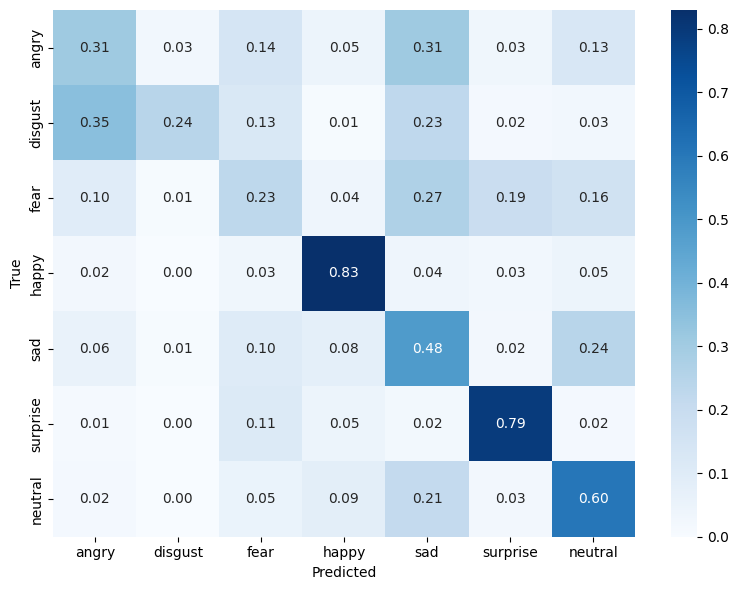

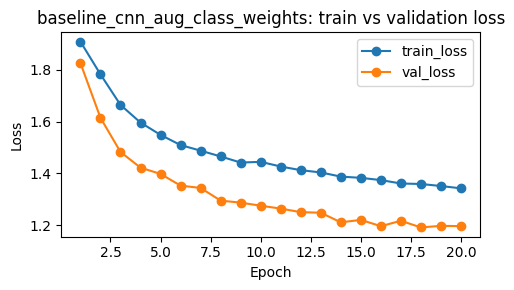

,epoch,train_loss,val_loss
0,1,1.909478,1.826690
1,2,1.782975,1.614833
2,3,1.664648,1.482617
3,4,1.596313,1.421825
4,5,1.548707,1.397704
5,6,1.509324,1.352375
6,7,1.487631,1.343363
7,8,1.465284,1.294409
8,9,1.441639,1.286618
9,10,1.444392,1.274705


,precision,recall,f1-score,support
macro avg,0.510028,0.498528,0.496053,7178.0
weighted avg,0.553644,0.561995,0.551170,7178.0


,precision,recall,f1-score,support
angry,0.507719,0.308977,0.384166,958.0
disgust,0.360000,0.243243,0.290323,111.0
fear,0.320600,0.229492,0.267501,1024.0
happy,0.816768,0.829200,0.822937,1774.0
sad,0.389787,0.483561,0.431639,1247.0
surprise,0.658659,0.791817,0.719126,831.0
neutral,0.516667,0.603406,0.556678,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
29,sad,neutral,303,0.242983
3,angry,sad,297,0.310021
15,fear,sad,273,0.266602
39,neutral,sad,263,0.213301
16,fear,surprise,199,0.194336
17,fear,neutral,167,0.163086
1,angry,fear,137,0.143006
26,sad,fear,130,0.104250
5,angry,neutral,126,0.131524
38,neutral,happy,106,0.085969


In [9]:
history_weight, report_weight, confusions_weight = run_stage('baseline_cnn_aug_class_weights')

### Stage 4: Optional Imbalance Alternatives

Use these only if class weights are not enough. Run one option at a time, then compare the saved results. Weighted sampling changes which examples appear in batches; focal loss changes the loss so harder examples receive more emphasis.


USING SQRT WEIGHTS


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.9123, 'train_accuracy': 0.2059, 'val_loss': 1.7922, 'val_accuracy': 0.2638}


  0%|          | 0/202 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 19, 'train_loss': 1.3488, 'train_accuracy': 0.4724, 'val_loss': 1.1225, 'val_accuracy': 0.5798}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 20, 'train_loss': 1.3369, 'train_accuracy': 0.4749, 'val_loss': 1.1144, 'val_accuracy': 0.5833}


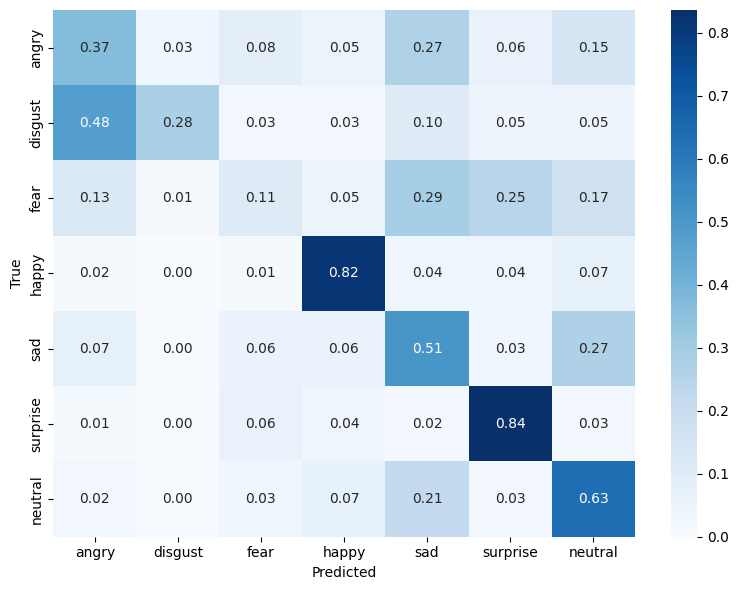

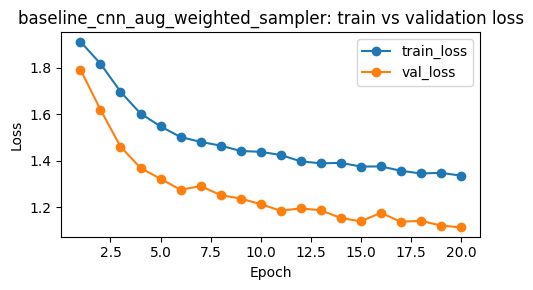

,epoch,train_loss,val_loss
0,1,1.912284,1.792189
1,2,1.817711,1.620260
2,3,1.697372,1.461681
3,4,1.603499,1.369756
4,5,1.548219,1.323270
5,6,1.502496,1.276111
6,7,1.481844,1.291960
7,8,1.465649,1.253349
8,9,1.442788,1.238260
9,10,1.439153,1.214290


,precision,recall,f1-score,support
macro avg,0.502426,0.507339,0.491430,7178.0
weighted avg,0.547346,0.565060,0.543895,7178.0


,precision,recall,f1-score,support
angry,0.504298,0.367432,0.425121,958.0
disgust,0.378049,0.279279,0.321244,111.0
fear,0.292553,0.107422,0.157143,1024.0
happy,0.836982,0.819053,0.827920,1774.0
sad,0.407598,0.507618,0.452143,1247.0
surprise,0.602253,0.836342,0.700252,831.0
neutral,0.495250,0.634225,0.556188,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
28,sad,neutral,338,0.271051
15,fear,sad,300,0.292969
38,neutral,sad,262,0.212490
3,angry,sad,254,0.265136
16,fear,surprise,251,0.245117
17,fear,neutral,173,0.168945
5,angry,neutral,139,0.145094
12,fear,angry,130,0.126953
22,happy,neutral,119,0.067080
23,sad,angry,93,0.074579


In [8]:
SELECTED_IMBALANCE_EXPERIMENT = 'baseline_cnn_aug_weighted_sampler'
history, report, confusions = run_stage(SELECTED_IMBALANCE_EXPERIMENT)


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.3122, 'train_accuracy': 0.2419, 'val_loss': 1.2043, 'val_accuracy': 0.2847}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 19, 'train_loss': 0.757, 'train_accuracy': 0.5278, 'val_loss': 0.6427, 'val_accuracy': 0.5808}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 20, 'train_loss': 0.7457, 'train_accuracy': 0.5286, 'val_loss': 0.6348, 'val_accuracy': 0.5889}


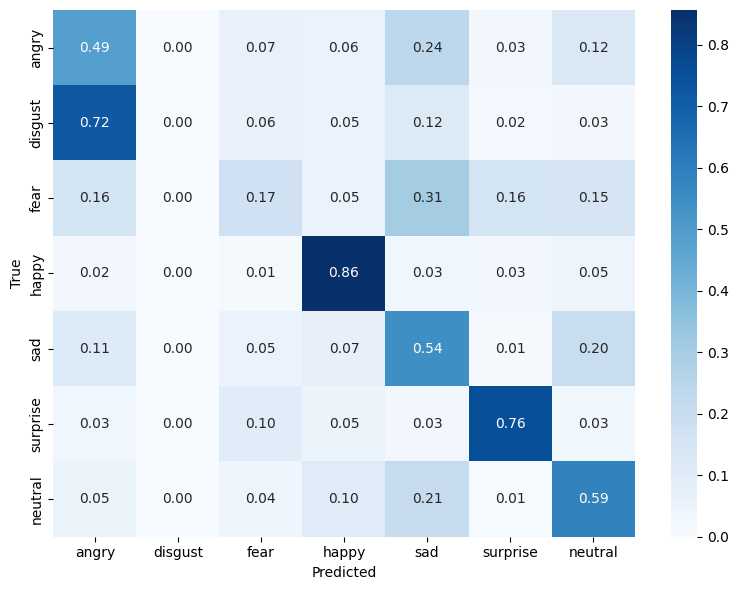

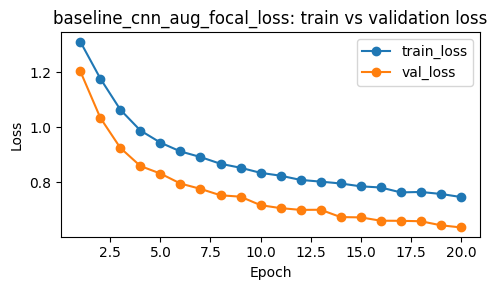

,epoch,train_loss,val_loss
0,1,1.312235,1.204336
1,2,1.177668,1.034485
2,3,1.064023,0.924721
3,4,0.988203,0.858727
4,5,0.944066,0.831227
5,6,0.911927,0.794861
6,7,0.891513,0.775438
7,8,0.866906,0.752049
8,9,0.852424,0.746954
9,10,0.833913,0.716001


,precision,recall,f1-score,support
macro avg,0.474598,0.486115,0.473397,7178.0
weighted avg,0.563178,0.584146,0.566391,7178.0


,precision,recall,f1-score,support
angry,0.474974,0.485386,0.480124,958.0
disgust,0.000000,0.000000,0.000000,111.0
fear,0.382479,0.174805,0.239946,1024.0
happy,0.801265,0.856821,0.828112,1774.0
sad,0.429386,0.543705,0.479830,1247.0
surprise,0.703247,0.755716,0.728538,831.0
neutral,0.530837,0.586375,0.557225,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
13,fear,sad,315,0.307617
34,neutral,sad,262,0.212490
25,sad,neutral,254,0.203689
2,angry,sad,228,0.237996
11,fear,angry,161,0.157227
14,fear,surprise,161,0.157227
15,fear,neutral,152,0.148438
21,sad,angry,141,0.113071
33,neutral,happy,128,0.103812
4,angry,neutral,119,0.124217


In [10]:
SELECTED_IMBALANCE_EXPERIMENT02 = 'baseline_cnn_aug_focal_loss'
history, report, confusions = run_stage(SELECTED_IMBALANCE_EXPERIMENT02)

### Stage 5: Transfer Learning Comparison

Run transfer learning after the self-defined CNN tuning path. Start with the frozen ResNet18 classifier to test fixed pretrained features, then fine-tune ResNet18 to test whether adapting the backbone improves FER2013 performance.


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.6816, 'train_accuracy': 0.327, 'val_loss': 1.5946, 'val_accuracy': 0.3704}


...

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 9, 'train_loss': 1.4836, 'train_accuracy': 0.4294, 'val_loss': 1.5047, 'val_accuracy': 0.424}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 10, 'train_loss': 1.4819, 'train_accuracy': 0.4291, 'val_loss': 1.5407, 'val_accuracy': 0.4073}


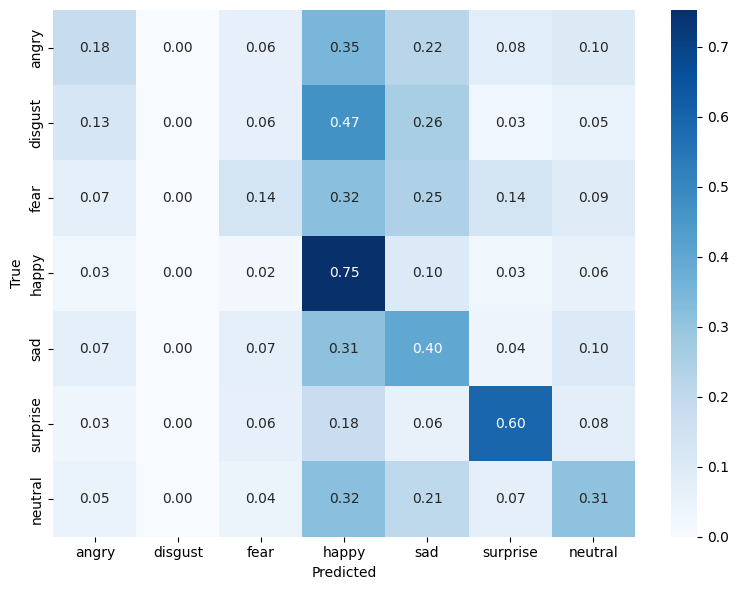

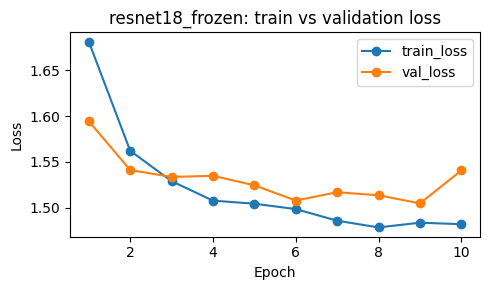

,epoch,train_loss,val_loss
0,1,1.681562,1.594615
1,2,1.562227,1.541130
2,3,1.529013,1.533617
3,4,1.507694,1.534838
4,5,1.504343,1.524491
5,6,1.498449,1.507795
6,7,1.485780,1.516900
7,8,1.478404,1.513530
8,9,1.483598,1.504716
9,10,1.481933,1.540722


,precision,recall,f1-score,support
macro avg,0.348788,0.339847,0.327406,7178.0
weighted avg,0.400518,0.421845,0.390130,7178.0


,precision,recall,f1-score,support
angry,0.357290,0.181628,0.240830,958.0
disgust,0.000000,0.000000,0.000000,111.0
fear,0.316742,0.136719,0.190996,1024.0
happy,0.447686,0.752537,0.561396,1774.0
sad,0.338047,0.402566,0.367496,1247.0
surprise,0.542169,0.595668,0.567661,831.0
neutral,0.439586,0.309813,0.363463,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
33,neutral,happy,395,0.320357
23,sad,happy,392,0.314354
1,angry,happy,335,0.349687
12,fear,happy,327,0.319336
34,neutral,sad,257,0.208435
13,fear,sad,251,0.245117
2,angry,sad,213,0.222338
18,happy,sad,186,0.104848
28,surprise,happy,146,0.175692
14,fear,surprise,140,0.136719


In [11]:
SELECTED_TRANSFER_EXPERIMENT = 'resnet18_frozen'

history, report, confusions = run_stage(SELECTED_TRANSFER_EXPERIMENT)

  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.2116, 'train_accuracy': 0.5372, 'val_loss': 1.0195, 'val_accuracy': 0.6139}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 9, 'train_loss': 0.4611, 'train_accuracy': 0.8347, 'val_loss': 1.0538, 'val_accuracy': 0.6526}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 10, 'train_loss': 0.4095, 'train_accuracy': 0.8531, 'val_loss': 1.095, 'val_accuracy': 0.6592}


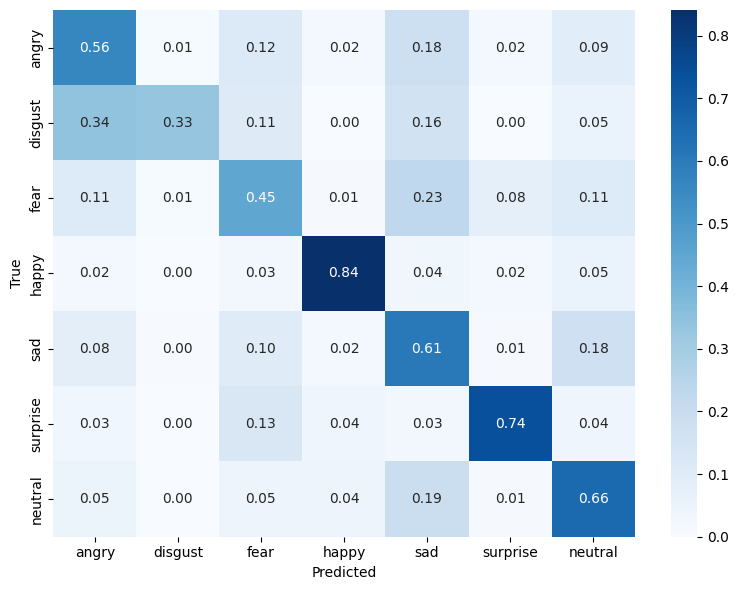

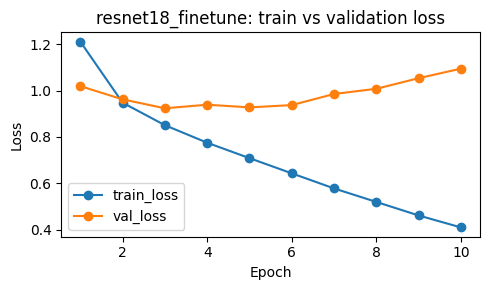

,epoch,train_loss,val_loss
0,1,1.211621,1.019481
1,2,0.947972,0.962352
2,3,0.850833,0.923796
3,4,0.775129,0.939245
4,5,0.708588,0.927699
5,6,0.642988,0.937646
6,7,0.577796,0.985597
7,8,0.519476,1.008104
8,9,0.461133,1.053800
9,10,0.409470,1.095021


,precision,recall,f1-score,support
macro avg,0.64173,0.598170,0.612807,7178.0
weighted avg,0.66542,0.655754,0.658178,7178.0


,precision,recall,f1-score,support
angry,0.591658,0.562630,0.576779,958.0
disgust,0.606557,0.333333,0.430233,111.0
fear,0.501082,0.452148,0.475359,1024.0
happy,0.913097,0.841037,0.875587,1774.0
sad,0.501995,0.605453,0.548891,1247.0
surprise,0.784615,0.736462,0.759777,831.0
neutral,0.593109,0.656123,0.623027,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
37,neutral,sad,238,0.193025
13,fear,sad,235,0.229492
26,sad,neutral,220,0.176423
3,angry,sad,172,0.179541
23,sad,fear,124,0.099439
1,angry,fear,112,0.116910
10,fear,angry,112,0.109375
15,fear,neutral,112,0.109375
29,surprise,fear,107,0.128761
21,sad,angry,104,0.083400


In [13]:
SELECTED_TRANSFER_EXPERIMENT02 = 'resnet18_finetune'
history, report, confusions = run_stage(SELECTED_TRANSFER_EXPERIMENT02)

In [16]:
# Continuing to train model with a lower lr
config = EXPERIMENTS_BY_NAME['resnet18_finetune']

loaders, datasets = build_imagefolder_dataloaders(
    DATA_DIR,
    train_config=config['train_config'],
    eval_config=config['eval_config'],
    batch_size=64,
    num_workers=2,
    weighted_sampler=config.get('weighted_sampler', False),
    val_fraction=0.1,
    subset_fraction=1.0,
    seed=SEED,
)

model = build_model(
    'transfer',
    transfer_model='resnet18',
    freeze_backbone=False,
)

checkpoint_path = RESULTS_DIR / 'checkpoints' / 'resnet18_finetune.pt'
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))

extra_history = fit(
    model,
    loaders,
    device=DEVICE,
    epochs=10,          # additional epochs
    lr=5e-5,            # use lower LR when continuing
    checkpoint_path=checkpoint_path,
)


  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.7633, 'train_accuracy': 0.7173, 'val_loss': 0.9078, 'val_accuracy': 0.67}


  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

...

  0%|          | 0/45 [00:00<?, ?it/s]

{'epoch': 3, 'train_loss': 0.6429, 'train_accuracy': 0.7674, 'val_loss': 0.9368, 'val_accuracy': 0.6714}


  0%|          | 0/404 [00:00<?, ?it/s]

Exception in thread Thread-19 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource_

KeyboardInterrupt: 

### Merge Finished Results

Use this only after you have finished several separate runs. It reads saved metric files and displays one comparison table without retraining. The purpose is convenience, not replacing the visible F1/loss outputs above.


In [ ]:
summary_rows = {}
metrics_dir = RESULTS_DIR / 'metrics'

for config in CORE_EXPERIMENTS + OPTIONAL_EXPERIMENTS:
    name = config['name']
    report_path = metrics_dir / f'{name}_classification_report.csv'
    history_path = metrics_dir / f'{name}_history.csv'
    confusions_path = metrics_dir / f'{name}_top_confusions.csv'
    if not report_path.exists() or not history_path.exists():
        continue

    report = pd.read_csv(report_path, index_col=0)
    history = pd.read_csv(history_path)
    confusions = pd.read_csv(confusions_path) if confusions_path.exists() else pd.DataFrame()
    summary_rows[name] = {
        'group': config['group'],
        'final_val_loss': float(history['val_loss'].iloc[-1]),
        'best_val_loss': float(history['val_loss'].min()),
        'test_macro_f1': float(report.loc['macro avg', 'f1-score']),
        'test_weighted_f1': float(report.loc['weighted avg', 'f1-score']),
        'top_confusion': 'none' if confusions.empty else f"{confusions.iloc[0]['true_emotion']} -> {confusions.iloc[0]['predicted_emotion']}",
    }

summary = pd.DataFrame(summary_rows).T.sort_values('test_macro_f1', ascending=False)
summary.to_csv(metrics_dir / 'experiment_summary.csv')
summary


In [17]:
%cd /kaggle/working/DL-final-project

/kaggle/working/DL-final-project


## 6. Report Checklist

- Start the report from dataset evidence: 48x48 grayscale images, class imbalance, visual ambiguity, and train/test split sizes.
- Treat `CORE_EXPERIMENTS` as the minimum protocol for the instructor feedback.
- Present the self-defined CNN as a staged tuning path: baseline CNN, augmentation, class weighting, then optional imbalance alternatives.
- Explain why ResNet18 is the main pretrained backbone: standard, moderate-size, ImageNet-pretrained, and practical for frozen-vs-fine-tuned transfer learning.
- Explain why MobileNetV2 is added: a lightweight pretrained backbone for efficiency-oriented comparison against ResNet18.
- If time allows, run `OPTIONAL_EXPERIMENTS` to strengthen the imbalance and transfer-learning sections.
- Select the best model by macro F1 because FER2013 is imbalanced.
- Use weighted F1 and per-class precision/recall/F1 as supporting metrics.
- Do not use accuracy for model selection or report conclusions.
- Use confusion matrices and each `_top_confusions.csv` file to discuss confused emotions and failure cases.
- Explain the transfer learning input adaptation: 48x48 grayscale images are converted to 3-channel 224x224 tensors with ImageNet normalization.
- Discuss which modeling choice improved minority or ambiguous classes, even if total accuracy did not improve.
